In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import csv

# Load labels from CSV
label_dict = {}
with open('trainLabels.csv', 'r') as f:
    reader = csv.reader(f)
    next(reader)  # skip header
    for row in reader:
        label_dict[row[0]] = row[1]

# Get all image filenames
labels = []
image_dir = 'train\\train'
imageList = os.listdir(image_dir)
images = [plt.imread(os.path.join(image_dir, f)) for f in imageList ]
class_names = {'airplane':0,'automobile':1,'bird':2,'cat':3,'deer':4,'dog':5,'frog':6,'horse':7,'ship':8,'truck':9}
    
temp = np.loadtxt('trainLabels.csv', delimiter=',', skiprows=1,dtype=str)
for name in (temp):
    labels.append(class_names[name[1]])

images = np.array(images)
labels = np.array(labels)


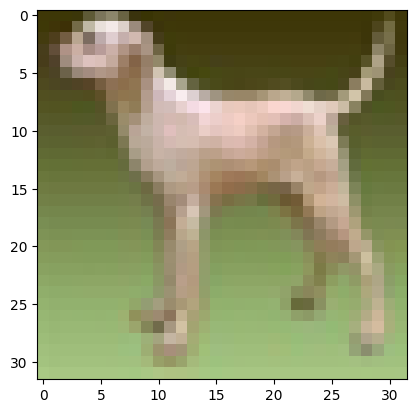

In [7]:
plt.imshow(images[4])
plt.show()

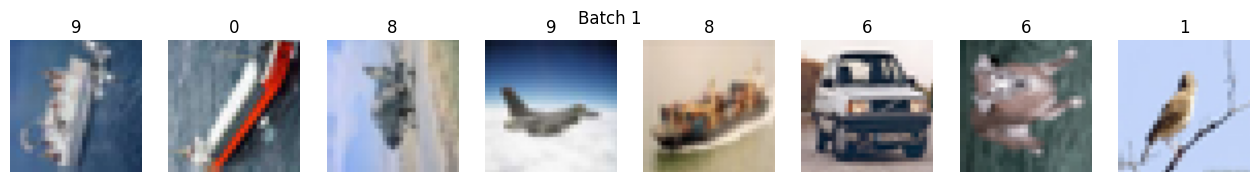

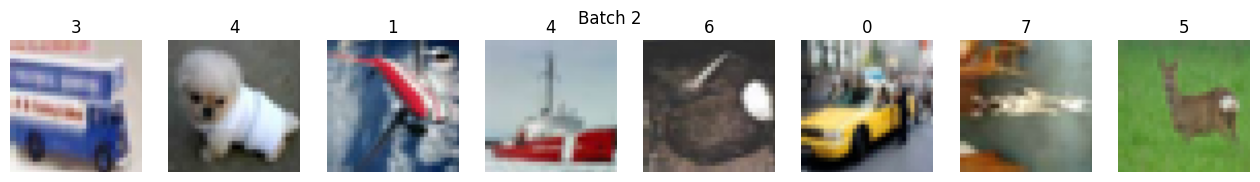

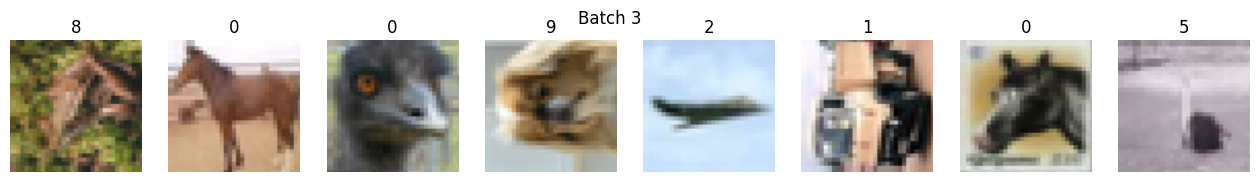

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def resize_image(img, new_size=(64, 64)):
    """Resize image using nearest neighbor interpolation."""
    h, w = img.shape[:2]
    new_h, new_w = new_size
    row_idx = (np.linspace(0, h-1, new_h)).astype(int)
    col_idx = (np.linspace(0, w-1, new_w)).astype(int)
    return img[row_idx][:, col_idx]

def random_rotate_90(img):
    """Randomly rotate image by 0 or 90 degrees."""
    k = np.random.choice([0, 1])
    return np.rot90(img, k)

def transform(img):
    img = resize_image(img, (64, 64))
    img = random_rotate_90(img)
    return img

def dataloader(images, labels, batch_size=8):
    idxs = np.arange(len(images))
    np.random.shuffle(idxs)
    for i in range(0, len(images), batch_size):
        batch_idxs = idxs[i:i+batch_size]
        yield images[batch_idxs], labels[batch_idxs]

# Visualization 
batch_size = 8
loader = dataloader(images, labels, batch_size=batch_size)

for batch_num, (batch_imgs, batch_labels) in enumerate(loader):
    batch_imgs = np.array([transform(img) for img in batch_imgs])
    plt.figure(figsize=(16, 2))
    for i in range(len(batch_imgs)):
        plt.subplot(1, batch_size, i+1)
        plt.imshow(batch_imgs[i])
        plt.title(str(batch_labels[i]))
        plt.axis('off')
    plt.suptitle(f'Batch {batch_num+1}')
    plt.show()
    if batch_num == 2:
        break

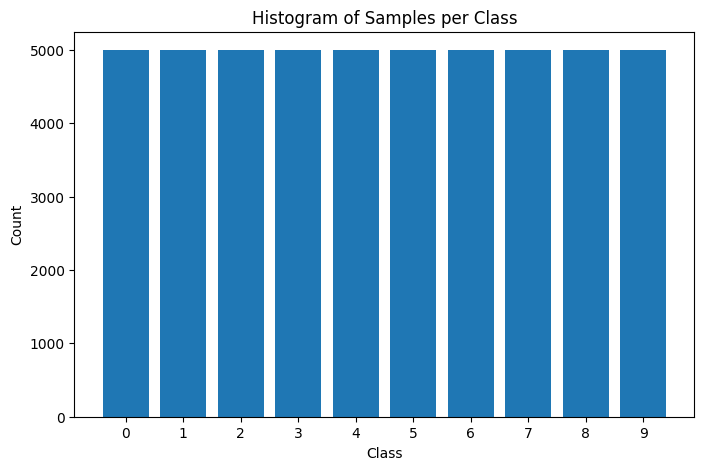

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#by assuming labels is a numpy array of class indices 
num_classes = len(np.unique(labels))

plt.figure(figsize=(8, 5))
plt.hist(labels, bins=np.arange(num_classes+1)-0.5, rwidth=0.8)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Histogram of Samples per Class')
plt.xticks(range(num_classes))
plt.show()

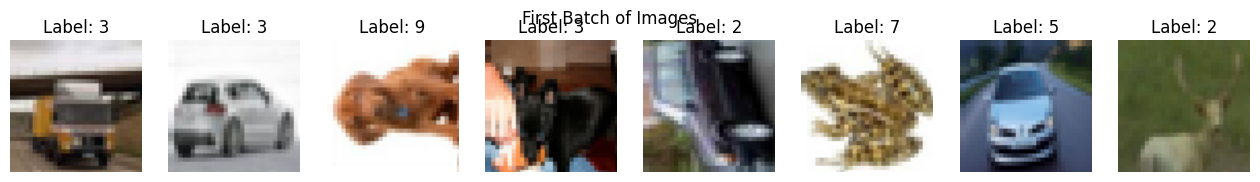

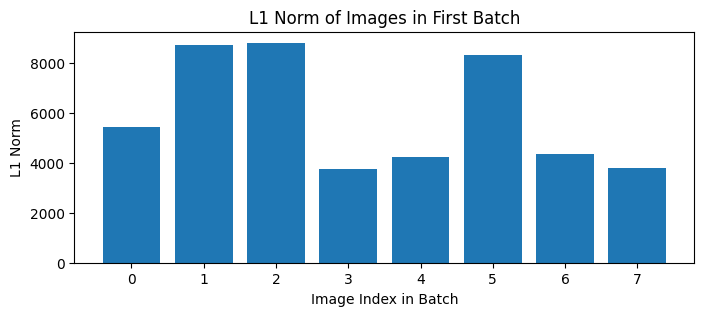

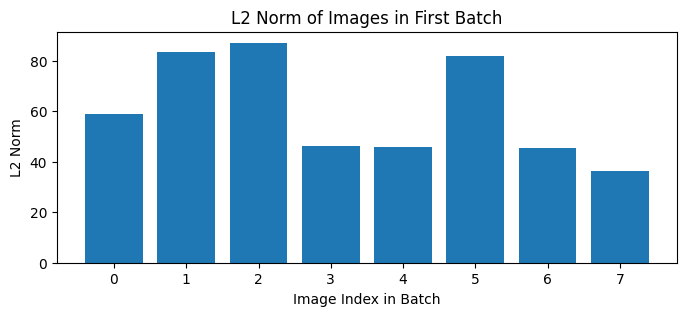

In [10]:

batch_size = 8
loader = dataloader(images, labels, batch_size=batch_size)
batch_imgs, batch_labels = next(loader)
batch_imgs = np.array([transform(img) for img in batch_imgs])

plt.figure(figsize=(16, 2))
for i in range(batch_size):
    plt.subplot(1, batch_size, i+1)
    plt.imshow(batch_imgs[i])
    plt.title(f"Label: {batch_labels[i]}")
    plt.axis('off')
plt.suptitle('First Batch of Images')
plt.show()

l1_norms = [np.sum(np.abs(img)) for img in batch_imgs]
l2_norms = [np.sqrt(np.sum(img.astype(np.float64)**2)) for img in batch_imgs]


plt.figure(figsize=(8, 3))
plt.bar(range(batch_size), l1_norms)
plt.xlabel('Image Index in Batch')
plt.ylabel('L1 Norm')
plt.title('L1 Norm of Images in First Batch')
plt.show()


plt.figure(figsize=(8, 3))
plt.bar(range(batch_size), l2_norms)
plt.xlabel('Image Index in Batch')
plt.ylabel('L2 Norm')
plt.title('L2 Norm of Images in First Batch')
plt.show()

In [11]:
import numpy as np

# part (a) 
def center_crop(img, crop_size=(64, 64)):
    h, w = img.shape[:2]
    ch, cw = crop_size
    start_h = (h - ch) // 2
    start_w = (w - cw) // 2
    return img[start_h:start_h+ch, start_w:start_w+cw]

# part (b) 
def preprocess_images(images):
    cropped = np.array([center_crop(img, (64, 64)) for img in images])
    flat = cropped.reshape(len(cropped), -1)
    return flat

# part (c)
class SimpleNet:
    def __init__(self, input_dim, hidden1, hidden2, output_dim, activation='relu', lr=0.01):
        self.W1 = np.random.randn(input_dim, hidden1) * 0.01
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.randn(hidden1, hidden2) * 0.01
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.randn(hidden2, output_dim) * 0.01
        self.b3 = np.zeros((1, output_dim))
        self.lr = lr
        self.activation = activation

    def act(self, x):
        if self.activation == 'relu':
            return np.maximum(0, x)
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        elif self.activation == 'tanh':
            return np.tanh(x)
        else:
            raise ValueError("Unknown activation")

    def act_deriv(self, x):
        if self.activation == 'relu':
            return (x > 0).astype(float)
        elif self.activation == 'sigmoid':
            s = 1 / (1 + np.exp(-x))
            return s * (1 - s)
        elif self.activation == 'tanh':
            return 1 - np.tanh(x) ** 2
        else:
            raise ValueError("Unknown activation")

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.act(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.act(self.Z2)
        self.Z3 = self.A2 @ self.W3 + self.b3
        self.out = self.Z3 
        return self.out

    def backward(self, X, y):
        m = X.shape[0]
        dZ3 = (self.out - y) * 2 / m  # L2 loss gradient
        dW3 = self.A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dA2 = dZ3 @ self.W3.T
        dZ2 = dA2 * self.act_deriv(self.Z2)
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.act_deriv(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        grad_norm = np.linalg.norm(dW1) + np.linalg.norm(dW2) + np.linalg.norm(dW3)
        return grad_norm

    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)


images_100 = images[:100]
labels_100 = labels[:100]
X = preprocess_images(images_100)  # shape: (100, 64*64*3)
y = np.zeros((100, 10))
for i, label in enumerate(labels_100):
    y[i, int(label)] = 1  # one-hot encoding

#Train for each activation
for activation in ['relu', 'sigmoid', 'tanh']:
    print(f"\nActivation: {activation}")
    net = SimpleNet(input_dim=X.shape[1], hidden1=128, hidden2=64, output_dim=10, activation=activation, lr=0.01)
    for epoch in range(10):
        y_pred = net.forward(X)
        loss = net.compute_loss(y_pred, y)
        grad_norm = net.backward(X, y)
        print(f"Epoch {epoch+1}: lr={net.lr:.4f}, loss={loss:.4f}, grad_norm={grad_norm:.4f}")
        


Activation: relu
Epoch 1: lr=0.0100, loss=0.0999, grad_norm=0.1068
Epoch 2: lr=0.0100, loss=0.0995, grad_norm=0.1051
Epoch 3: lr=0.0100, loss=0.0991, grad_norm=0.1038
Epoch 4: lr=0.0100, loss=0.0986, grad_norm=0.1028
Epoch 5: lr=0.0100, loss=0.0982, grad_norm=0.1012
Epoch 6: lr=0.0100, loss=0.0979, grad_norm=0.0997
Epoch 7: lr=0.0100, loss=0.0975, grad_norm=0.0978
Epoch 8: lr=0.0100, loss=0.0971, grad_norm=0.0967
Epoch 9: lr=0.0100, loss=0.0968, grad_norm=0.0954
Epoch 10: lr=0.0100, loss=0.0965, grad_norm=0.0940

Activation: sigmoid
Epoch 1: lr=0.0100, loss=0.0994, grad_norm=2.7082
Epoch 2: lr=0.0100, loss=0.0934, grad_norm=1.7909
Epoch 3: lr=0.0100, loss=0.0907, grad_norm=1.1853
Epoch 4: lr=0.0100, loss=0.0896, grad_norm=0.7841
Epoch 5: lr=0.0100, loss=0.0891, grad_norm=0.5184
Epoch 6: lr=0.0100, loss=0.0889, grad_norm=0.3427
Epoch 7: lr=0.0100, loss=0.0888, grad_norm=0.2264
Epoch 8: lr=0.0100, loss=0.0887, grad_norm=0.1497
Epoch 9: lr=0.0100, loss=0.0887, grad_norm=0.0990
Epoch 10: 

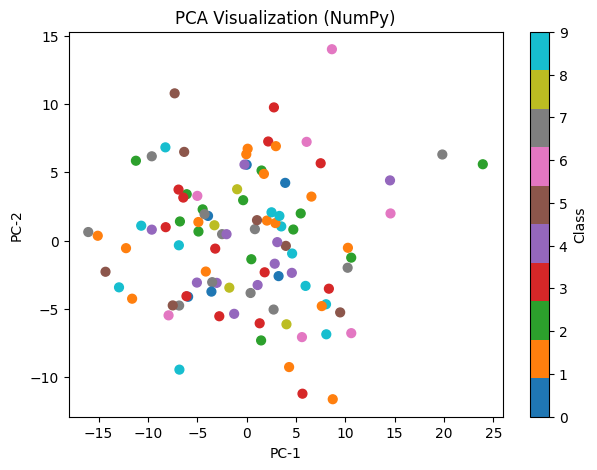

Iteration 100: error 0.3772
Iteration 200: error 0.3649
Iteration 300: error 0.3649
Iteration 400: error 0.3649
Iteration 500: error 0.3649


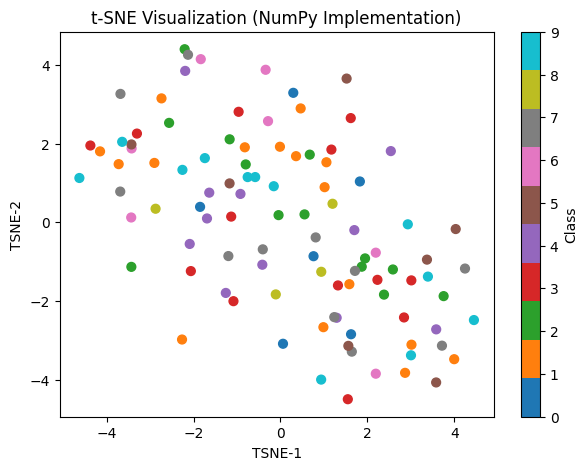

In [12]:
import numpy as np
import matplotlib.pyplot as plt


X = images_100.reshape(images_100.shape[0], -1)  # Flatten images to shape (100, 32*32*3)
y = labels_100

def pca_numpy(X, n_components=2):
    X_centered = X - np.mean(X, axis=0)
    _, _, Vt = np.linalg.svd(X_centered, full_matrices=False)
    X_proj = X_centered @ Vt.T[:, :n_components]
    return X_proj

X_pca = pca_numpy(X, n_components=2)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', s=40)
plt.title("PCA Visualization (NumPy)")
plt.xlabel("PC-1")
plt.ylabel("PC-2")
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.show()


def pairwise_distances(X):
    sum_X = np.sum(np.square(X), axis=1)
    return np.add.outer(sum_X, sum_X) - 2 * np.dot(X, X.T)
def Hbeta(D, beta=1.0):
    """Compute entropy and probability row given distances and precision beta."""
    P = np.exp(-D * beta)
    sumP = np.sum(P)
    if sumP == 0:
        sumP = 1e-12
    H = np.log(sumP) + beta * np.sum(D * P) / sumP
    P = P / sumP
    return H, P

def x2p(X, tol=1e-5, perplexity=30.0):
    """Compute joint probabilities P from high-dimensional data X."""
    (n, d) = X.shape
    D = pairwise_distances(X)
    P = np.zeros((n, n))
    beta = np.ones((n, 1))
    logU = np.log(perplexity)

    for i in range(n):
        betamin, betamax = -np.inf, np.inf
        Di = np.delete(D[i], i)  

        H, thisP = Hbeta(Di, beta[i])
        Hdiff = H - logU
        tries = 0

        while np.abs(Hdiff) > tol and tries < 50:
            if Hdiff > 0:
                betamin = beta[i].copy()
                beta[i] = (beta[i] * 2) if betamax == np.inf else (beta[i] + betamax) / 2
            else:
                betamax = beta[i].copy()
                beta[i] = (beta[i] / 2) if betamin == -np.inf else (beta[i] + betamin) / 2

            H, thisP = Hbeta(Di, beta[i])
            Hdiff = H - logU
            tries += 1

       
        P[i, np.concatenate((np.r_[0:i], np.r_[i+1:n]))] = thisP

    return P





def tsne(X, no_dims=2, initial_dims=50, perplexity=30.0, max_iter=500, lr=200.0):
   
    X_centered = X - np.mean(X, axis=0)
    _, _, Vt = np.linalg.svd(X_centered, full_matrices=False)
    initial_dims = min(initial_dims, X_centered.shape[1])
    X_reduced = X_centered @ Vt.T[:, :initial_dims]


    P = x2p(X_reduced, 1e-5, perplexity)
    P = (P + P.T) / (2 * X.shape[0])
    P = np.maximum(P, 1e-12)

    n = X.shape[0]
    Y = np.random.randn(n, no_dims)
    dY = np.zeros_like(Y)
    iY = np.zeros_like(Y)
    momentum = 0.5

    for iter in range(max_iter):
        sum_Y = np.sum(np.square(Y), axis=1)
        num = 1 / (1 + np.add.outer(sum_Y, sum_Y) - 2 * np.dot(Y, Y.T))
        np.fill_diagonal(num, 0)
        Q = num / np.sum(num)
        Q = np.maximum(Q, 1e-12)

        PQ = P - Q
        for i in range(n):
            dY[i,:] = np.sum((PQ[:,i][:,None] * num[:,i][:,None]) * (Y[i,:] - Y), axis=0)

        iY = momentum * iY - lr * dY
        Y += iY

        if iter == 100:
            momentum = 0.8
        if (iter+1) % 100 == 0:
            C = np.sum(P * np.log(P / Q))
            print(f"Iteration {iter+1}: error {C:.4f}")

    return Y


X_tsne = tsne(X, no_dims=2, initial_dims=50, perplexity=30.0, max_iter=500, lr=200.0)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='tab10', s=40)
plt.title("t-SNE Visualization (NumPy Implementation)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.show()
